1. Импортируем необходимые библиотеки

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

2. Импортируйте набор данных из файла heart.csv и поместите его в дата фрейм

In [17]:
df = pd.read_csv('heart.csv')
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


3. Получим сводную информацию по датафрейму

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


4. Гистограммы и распределение

Числовые признаки: ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output']


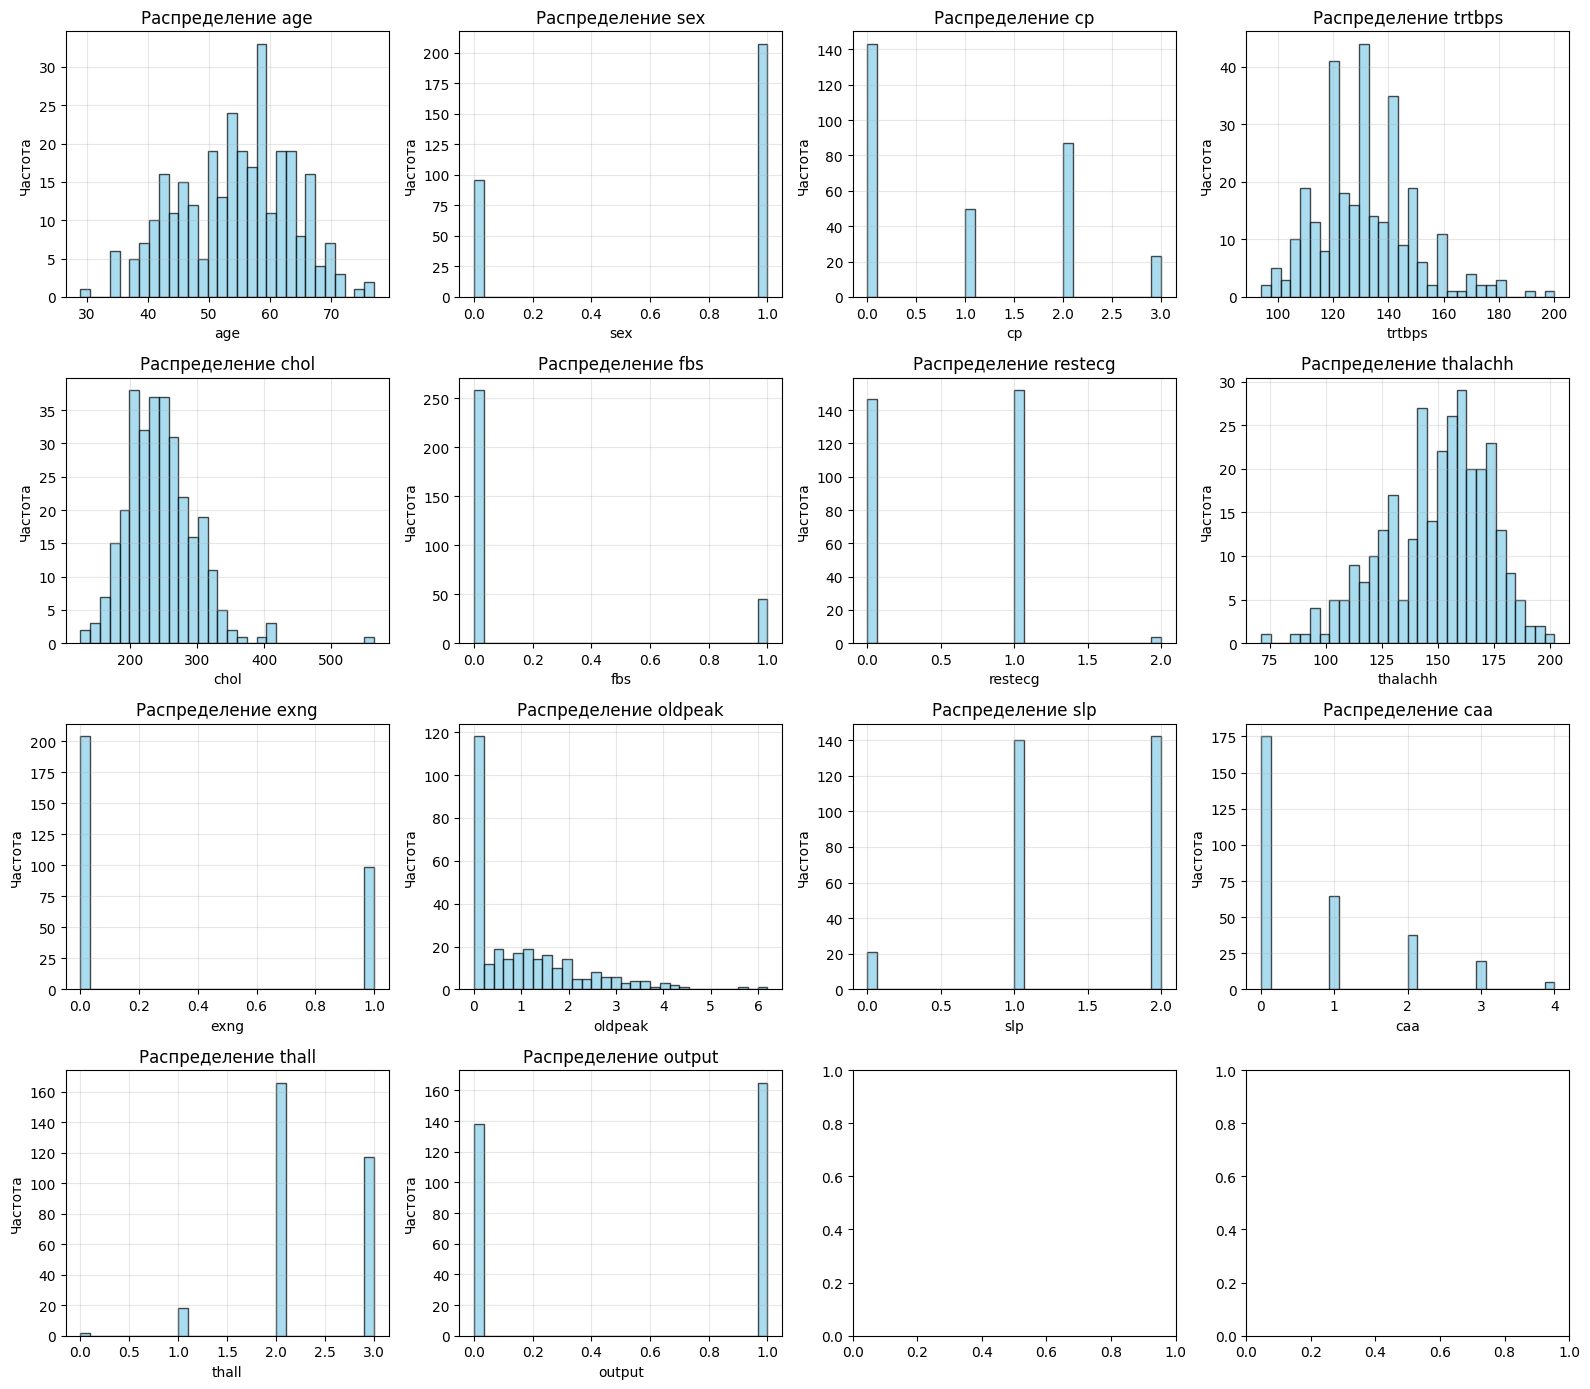

In [19]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Числовые признаки:", numeric_cols)

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


5. box-plot анализ выборов

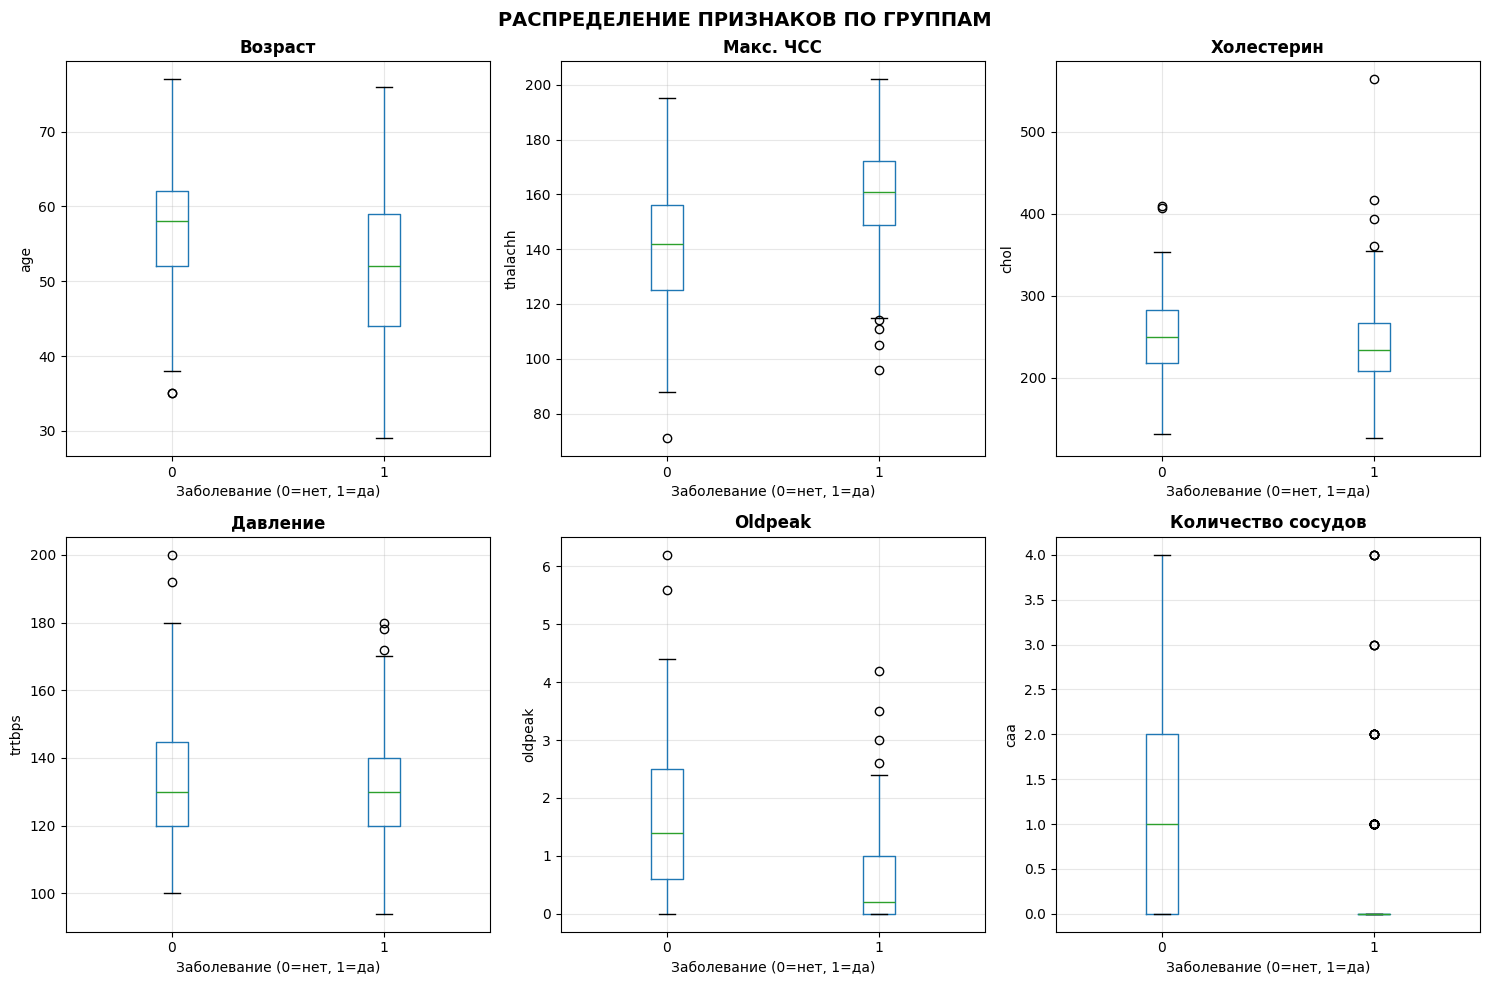

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Список признаков для анализа
features = ['age', 'thalachh', 'chol', 'trtbps', 'oldpeak', 'caa']
titles = ['Возраст', 'Макс. ЧСС', 'Холестерин', 'Давление', 'Oldpeak', 'Количество сосудов']

for i, (feature, title) in enumerate(zip(features, titles)):
    df.boxplot(column=feature, by='output', ax=axes[i])
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Заболевание (0=нет, 1=да)')
    axes[i].set_ylabel(feature)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('РАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ ПО ГРУППАМ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

6. Countplot для пола и типа боли в груди

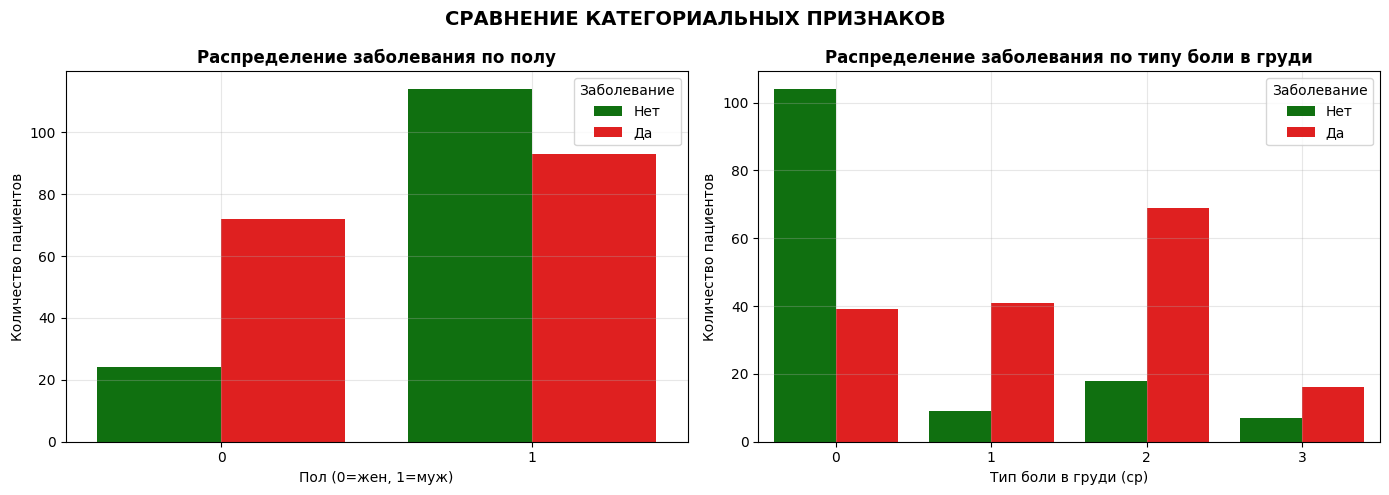

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Countplot по полу (sex)
sns.countplot(x='sex', hue='output', data=df, ax=axes[0], palette=['green', 'red'])
axes[0].set_title('Распределение заболевания по полу', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Пол (0=жен, 1=муж)')
axes[0].set_ylabel('Количество пациентов')
axes[0].legend(title='Заболевание', labels=['Нет', 'Да'])
axes[0].grid(True, alpha=0.3)

# 2. Countplot по типу боли в груди (cp)
sns.countplot(x='cp', hue='output', data=df, ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Распределение заболевания по типу боли в груди', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Тип боли в груди (cp)')
axes[1].set_ylabel('Количество пациентов')
axes[1].legend(title='Заболевание', labels=['Нет', 'Да'])
axes[1].grid(True, alpha=0.3)

plt.suptitle('СРАВНЕНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

7. Матрица диаграмм рассеяния

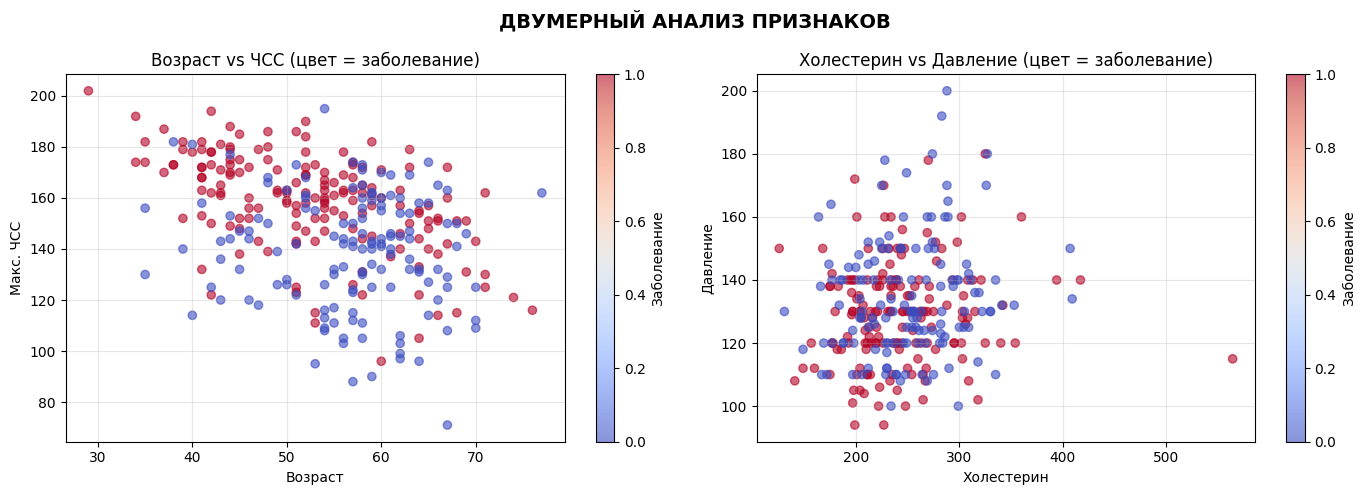

In [22]:
# Ячейка 9: Scatter plot (Рисунок 18)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Возраст vs ЧСС
scatter1 = axes[0].scatter(df['age'], df['thalachh'], 
                           c=df['output'], cmap='coolwarm', alpha=0.6)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Макс. ЧСС')
axes[0].set_title('Возраст vs ЧСС (цвет = заболевание)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Заболевание')

# Холестерин vs Давление
scatter2 = axes[1].scatter(df['chol'], df['trtbps'], 
                           c=df['output'], cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel('Холестерин')
axes[1].set_ylabel('Давление')
axes[1].set_title('Холестерин vs Давление (цвет = заболевание)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Заболевание')

plt.suptitle('ДВУМЕРНЫЙ АНАЛИЗ ПРИЗНАКОВ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

8. Матрица корреляций

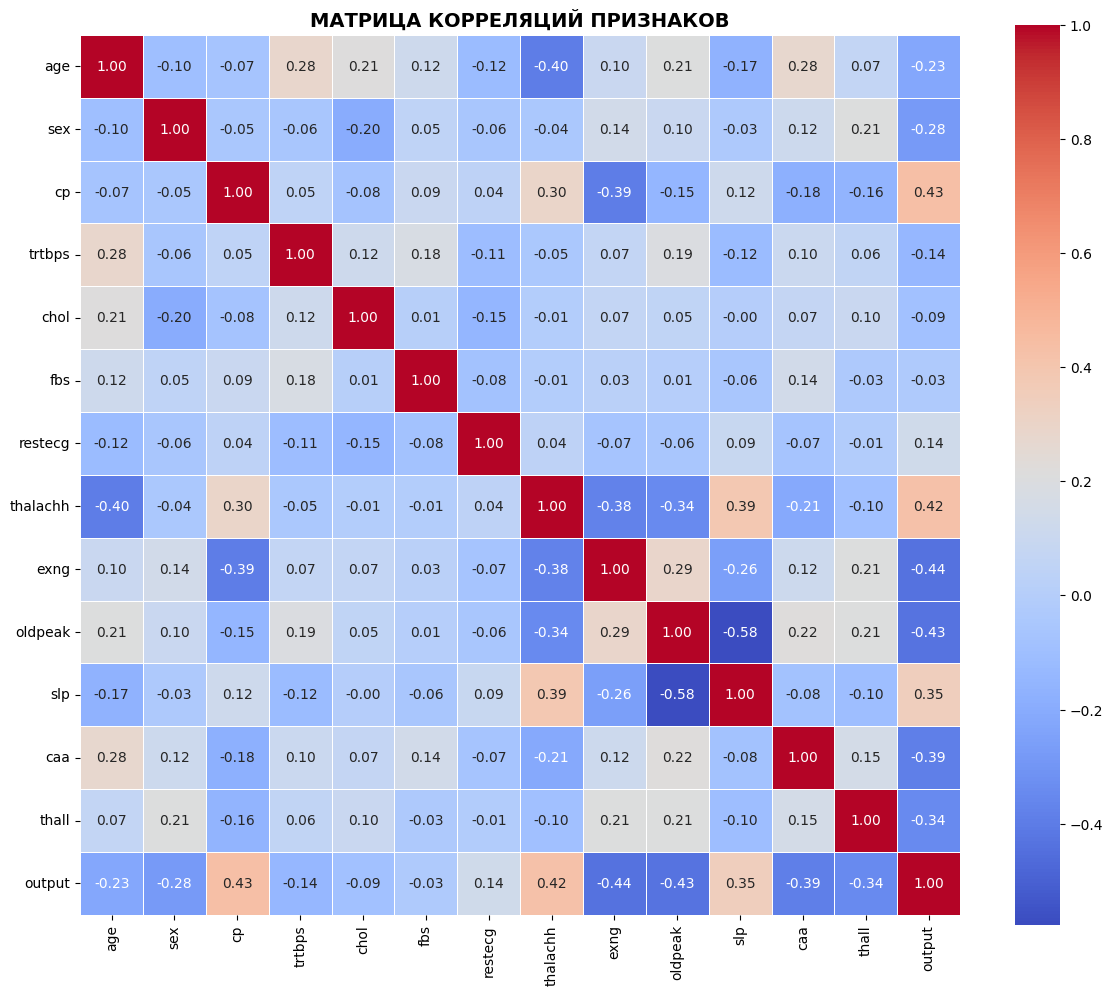

In [23]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('МАТРИЦА КОРРЕЛЯЦИЙ ПРИЗНАКОВ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()